# Prediksi Churn Pelanggan - Sales & Marketing Dataset
## Ujian Akhir Semester | Bengkel Koding Data Science
### Aditya Ulil Albab - A11.2023.15093 - DS-03

---

## A. Latar Belakang

Churn pelanggan terjadi ketika pelanggan berhenti menggunakan layanan atau tidak lagi melakukan pembelian. Kondisi ini merugikan perusahaan karena biaya mendapatkan pelanggan baru jauh lebih besar dibanding mempertahankan yang sudah ada.

Dataset yang digunakan adalah **Sales and Marketing Customer Dataset** dari Kaggle yang berisi informasi demografis, perilaku penggunaan layanan, riwayat transaksi, hingga interaksi pelanggan dengan perusahaan. Dari data ini akan dibangun model machine learning untuk memprediksi pelanggan mana yang berpotensi churn.

---

## B. Deskripsi Dataset

| Kolom | Tipe | Keterangan |
|---|---|---|
| customer_id | int64 | ID unik pelanggan |
| gender | object | Jenis kelamin |
| age | float64 | Usia pelanggan |
| country | object | Negara asal |
| city | object | Kota pelanggan |
| signup_date | object | Tanggal mendaftar |
| last_purchase_date | object | Tanggal transaksi terakhir |
| acquisition_channel | object | Sumber akuisisi pelanggan |
| device_type | object | Jenis perangkat |
| subscription_type | object | Jenis langganan |
| is_premium_user | int64 | Status premium (0/1) |
| total_visits | int64 | Total kunjungan |
| avg_session_time | float64 | Rata-rata durasi sesi |
| pages_per_session | float64 | Rata-rata halaman per sesi |
| email_open_rate | float64 | Tingkat buka email |
| email_click_rate | float64 | Tingkat klik email |
| total_spent | float64 | Total pengeluaran |
| avg_order_value | float64 | Rata-rata nilai transaksi |
| discount_used | int64 | Penggunaan diskon (0/1) |
| coupon_code | object | Kode kupon |
| support_tickets | int64 | Jumlah tiket support |
| refund_requested | int64 | Permintaan refund (0/1) |
| delivery_delay_days | int64 | Keterlambatan pengiriman |
| payment_method | object | Metode pembayaran |
| satisfaction_score | float64 | Skor kepuasan pelanggan |
| nps_score | int64 | Net Promoter Score |
| marketing_spend_per_user | float64 | Biaya marketing per pelanggan |
| lifetime_value | float64 | Nilai total pelanggan |
| last_3_month_purchase_freq | int64 | Frekuensi beli 3 bulan terakhir |
| churn | int64 | **Target**: status churn (0/1) |

---

## C. Tujuan Proyek

1. Melakukan eksplorasi data (EDA) untuk memahami struktur data, distribusi variabel, dan korelasi antar fitur.
2. Membangun tiga kategori model machine learning: konvensional, ensemble bagging, dan ensemble voting.
3. Mengevaluasi performa model melalui tiga skenario: direct, preprocessing, dan hyperparameter tuning.
4. Menghasilkan total 9 model dan memilih model terbaik berdasarkan metrik klasifikasi.
5. Melakukan deployment model terbaik ke Streamlit Cloud.

---

## D. Exploratory Data Analysis (EDA)

### D.1 Import Library dan Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Sales - Marketing customer dataset.csv')
print(f'Jumlah baris  : {df.shape[0]:,}')
print(f'Jumlah kolom  : {df.shape[1]}')

Jumlah baris  : 15,000
Jumlah kolom  : 30


### D.2 Lima Baris Pertama Dataset

In [3]:
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


### D.3 Informasi Dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  str    
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  str    
 4   city                        15000 non-null  str    
 5   signup_date                 15000 non-null  str    
 6   last_purchase_date          15000 non-null  str    
 7   acquisition_channel         15000 non-null  str    
 8   device_type                 15000 non-null  str    
 9   subscription_type           15000 non-null  str    
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           15000 non-null

### D.4 Statistik Deskriptif

In [5]:
df.describe()

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


### D.5 Analisis Missing Value

In [6]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print('Kolom dengan missing value:')
print(missing_pct.to_string())

Kolom dengan missing value:
coupon_code           40.886667
age                    8.000000
total_spent            7.000000
gender                 4.920000
satisfaction_score     4.680000


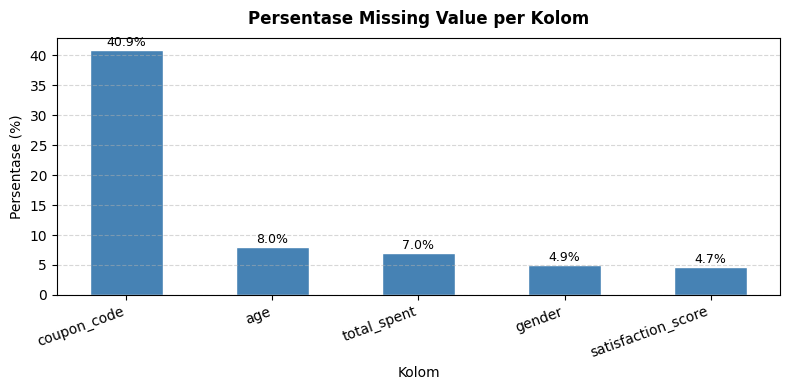

In [7]:
plt.figure(figsize=(8, 4))

plt.bar(missing_pct.index, missing_pct.values,
        color='steelblue', edgecolor='white', width=0.5)

plt.title('Persentase Missing Value per Kolom', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Kolom')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, val in enumerate(missing_pct.values):
    plt.text(i, val + 0.2, f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Insight:**  
Ada 5 kolom yang memiliki missing value. `coupon_code` paling banyak hilang (40.9%) karena memang tidak semua pelanggan memakai kupon, bukan berarti data rusak. Sementara `age`, `gender`, dan `satisfaction_score` yang hilang perlu ditangani di tahap preprocessing karena ketiganya relevan sebagai fitur model.

### D.6 Distribusi Variabel Target (Churn)

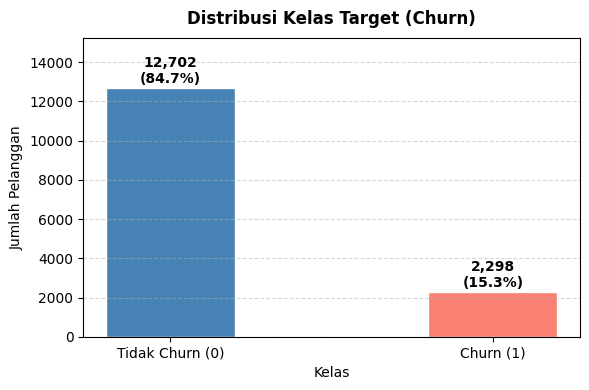

Tidak Churn (0) : 12,702 (84.7%)
Churn (1)       : 2,298 (15.3%)


In [8]:
churn_counts = df['churn'].value_counts()
labels = ['Tidak Churn (0)', 'Churn (1)']

plt.figure(figsize=(6, 4))

bars = plt.bar(labels, churn_counts.values,
               color=['steelblue', 'salmon'],
               edgecolor='white', width=0.4)

plt.title('Distribusi Kelas Target (Churn)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Kelas')
plt.ylabel('Jumlah Pelanggan')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar, val in zip(bars, churn_counts.values):
    pct = val / len(df) * 100
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 80,
             f'{val:,}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylim(0, churn_counts.max() * 1.2)
plt.tight_layout()
plt.show()

print(f'Tidak Churn (0) : {churn_counts[0]:,} ({churn_counts[0]/len(df)*100:.1f}%)')
print(f'Churn (1)       : {churn_counts[1]:,} ({churn_counts[1]/len(df)*100:.1f}%)')

**Insight:**  
Dataset tidak seimbang. Pelanggan yang tidak churn jauh lebih banyak (84.7%) dibanding yang churn (15.3%), dengan rasio sekitar 5.5:1. Kondisi ini perlu diperhatikan saat pemodelan karena model bisa saja condong memprediksi kelas mayoritas. Teknik seperti `class_weight='balanced'` atau resampling bisa menjadi solusi.

### D.7 Heatmap Korelasi Fitur Numerik

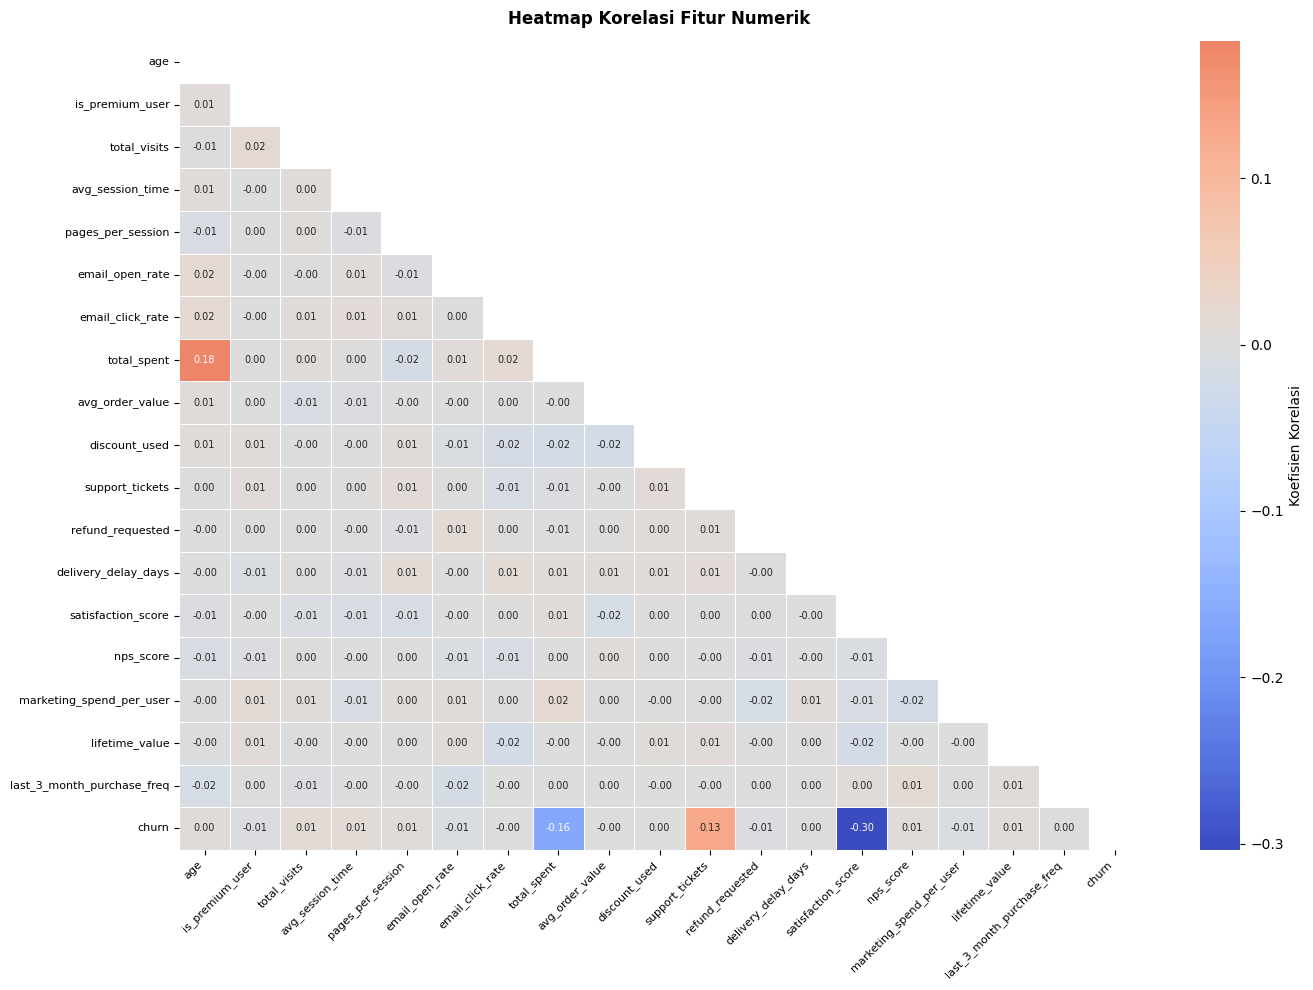

In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'customer_id']

corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 7},
    cbar_kws={'label': 'Koefisien Korelasi'}
)

plt.title('Heatmap Korelasi Fitur Numerik', fontsize=12, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [10]:
corr_churn = corr['churn'].drop('churn').sort_values(ascending=False)
print('Korelasi fitur terhadap Churn:')
print(corr_churn.to_string())

Korelasi fitur terhadap Churn:
support_tickets               0.127910
total_visits                  0.013212
avg_session_time              0.012198
lifetime_value                0.006250
pages_per_session             0.005871
nps_score                     0.005749
age                           0.004506
delivery_delay_days           0.001603
last_3_month_purchase_freq    0.001590
discount_used                 0.000265
avg_order_value              -0.001480
email_click_rate             -0.001752
is_premium_user              -0.005496
refund_requested             -0.006959
marketing_spend_per_user     -0.007315
email_open_rate              -0.008439
total_spent                  -0.163279
satisfaction_score           -0.303588


**Insight:**  
Secara umum tidak ada fitur yang berkorelasi tinggi terhadap `churn`, yang menunjukkan bahwa churn dipengaruhi oleh kombinasi banyak faktor, bukan satu variabel saja. `satisfaction_score` dan `nps_score` memiliki korelasi negatif terhadap churn, artinya semakin puas pelanggan semakin kecil kemungkinan churn. Sebaliknya, `support_tickets` dan `delivery_delay_days` berkorelasi positif, pelanggan yang sering komplain atau mengalami keterlambatan lebih rentan churn.

# E.Direct Model

### E.1 Import Library

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

### E.2 Penentuan Fitur dan Target

In [12]:
df_numeric = df.select_dtypes(include=[np.number]).dropna()
X = df_numeric.drop(columns=['churn', 'customer_id'], errors='ignore')
y = df_numeric['churn']

### E.3 Splitting Data

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### E.4 Inisiasi Model

In [14]:
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_rf = RandomForestClassifier(random_state=42)

model_knn = KNeighborsClassifier()
model_nb = GaussianNB()
model_voting = VotingClassifier(
    estimators=[('lr', model_lr), ('knn', model_knn), ('nb', model_nb)],
    voting='soft'
)

models = {
    'Logistic Regression (Konvensional)': model_lr,
    'Random Forest (Ensemble Bagging)': model_rf,
    'Voting Classifier (Ensemble Voting)': model_voting
}

### E.5 Pelatihan,Prediksi, dan Evaluasi

=== Logistic Regression (Konvensional) ===


Accuracy  : 0.8445
Precision : 0.5364
Recall    : 0.1517
F1-Score  : 0.2365



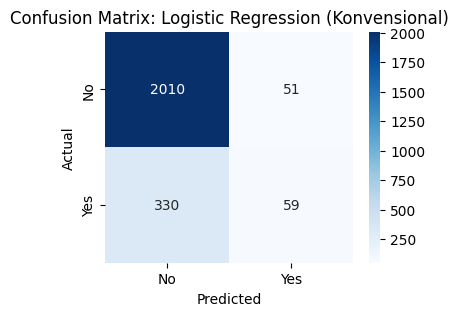

=== Random Forest (Ensemble Bagging) ===


Accuracy  : 0.8376
Precision : 0.4863
Recall    : 0.4113
F1-Score  : 0.4457



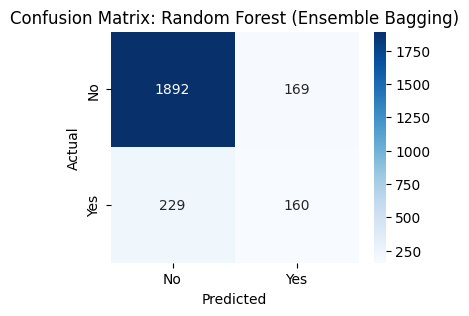

=== Voting Classifier (Ensemble Voting) ===


Accuracy  : 0.8412
Precision : 0.5000
Recall    : 0.1003
F1-Score  : 0.1670



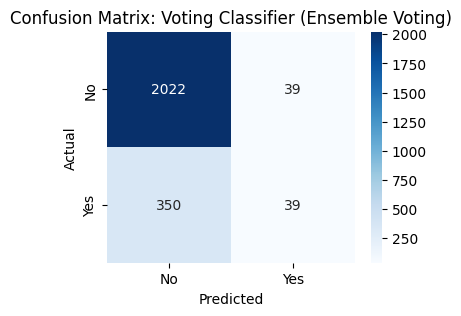

In [15]:
for name, model in models.items():
    print(f"=== {name} ===")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"Recall    : {recall_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"F1-Score  : {f1_score(y_test, y_pred, zero_division=0):.4f}\n")
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

### Insight:

Meskipun akurasi tinggi (~84%), semua model gagal mendeteksi *churn* dengan baik dilihat dari recall rendah karena data langsung dilatih tanpa preprocessing jadi imbalanced data. Random Forest menjadi model terbaik dengan F1-Score tertinggi (0.4420) dibandingkan Logistic Regression (0.2490) dan Voting Classifier (0.1627).

# F. Modeling Dengan Preprocessing

Pada tahap direct modeling sebelumnya, model dilatih hanya menggunakan kolom numerik yang baris baris bermasalahnya langsung dibuang `dropna`, tanpa penanganan kategori, outlier, maupun scaling. Pada tahap ini, dataset diproses lebih menyeluruh terlebih dahulu sebelum dilatih ulang dengan tiga model yang sama agar dapat dibandingkan secara adil.

### F.1 Import Library Tambahan

In [16]:
from sklearn.preprocessing import StandardScaler


### F.2 Penanganan Missing Value, Duplikasi, dan Outlier

#### F.2.1 Menyalin Dataset dan Mengecek Duplikasi

In [17]:
df_prep = df.copy()

print('Jumlah baris duplikat sebelum penghapusan:', df_prep.duplicated().sum())
df_prep = df_prep.drop_duplicates()
print('Jumlah baris setelah penghapusan duplikat :', df_prep.shape[0])


Jumlah baris duplikat sebelum penghapusan: 0
Jumlah baris setelah penghapusan duplikat : 15000


#### F.2.2 Memperbaiki Nilai Tidak Valid

In [18]:
# Usia tidak mungkin bernilai negatif, anggap sebagai data tidak valid lalu jadikan missing
n_invalid_age = (df_prep['age'] < 0).sum()
print('Jumlah age bernilai negatif (tidak valid):', n_invalid_age)

df_prep.loc[df_prep['age'] < 0, 'age'] = np.nan


Jumlah age bernilai negatif (tidak valid): 3


#### F.2.3 Penanganan Missing Value

In [19]:
# Kolom numerik diisi dengan median (robust terhadap outlier)
df_prep['age'] = df_prep['age'].fillna(df_prep['age'].median())
df_prep['total_spent'] = df_prep['total_spent'].fillna(df_prep['total_spent'].median())
df_prep['satisfaction_score'] = df_prep['satisfaction_score'].fillna(df_prep['satisfaction_score'].median())

# Kolom kategorikal gender diisi dengan modus
df_prep['gender'] = df_prep['gender'].fillna(df_prep['gender'].mode()[0])

# coupon_code: nilai kosong berarti pelanggan tidak memakai kupon (bukan data hilang)
df_prep['coupon_code'] = df_prep['coupon_code'].fillna('No Coupon')

sisa_missing = df_prep.isnull().sum()
print('Sisa missing value setelah penanganan:')
print(sisa_missing[sisa_missing > 0] if sisa_missing.sum() > 0 else 'Tidak ada missing value tersisa.')


Sisa missing value setelah penanganan:
Tidak ada missing value tersisa.


**Insight:**  
`coupon_code` sengaja tidak diisi dengan modus karena nilai kosongnya bukan data yang hilang secara acak, melainkan representasi pelanggan yang tidak memakai kupon sama sekali. Mengisinya dengan modus justru akan menghilangkan informasi penting tersebut, sehingga lebih tepat diberi kategori baru `'No Coupon'`.

#### F.2.4 Penanganan Outlier (IQR Capping)

In [20]:
outlier_cols = ['age', 'total_visits', 'avg_session_time', 'pages_per_session',
                'total_spent', 'avg_order_value', 'support_tickets',
                'delivery_delay_days', 'lifetime_value']

for col in outlier_cols:
    q1 = df_prep[col].quantile(0.25)
    q3 = df_prep[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    n_out = ((df_prep[col] < lower) | (df_prep[col] > upper)).sum()
    df_prep[col] = df_prep[col].clip(lower, upper)
    print(f'{col:22s} -> {n_out:4d} outlier di-capping ke rentang [{lower:.2f}, {upper:.2f}]')


age                    ->  215 outlier di-capping ke rentang [11.00, 59.00]
total_visits           ->   39 outlier di-capping ke rentang [3.00, 27.00]
avg_session_time       ->   45 outlier di-capping ke rentang [-0.15, 16.19]
pages_per_session      ->   33 outlier di-capping ke rentang [-0.05, 8.05]
total_spent            ->  119 outlier di-capping ke rentang [-232.53, 1233.57]
avg_order_value        ->   54 outlier di-capping ke rentang [-7.75, 127.67]


support_tickets        ->   79 outlier di-capping ke rentang [-2.00, 6.00]
delivery_delay_days    ->  184 outlier di-capping ke rentang [-1.00, 7.00]
lifetime_value         ->   56 outlier di-capping ke rentang [-663.54, 3082.70]


### F.3 Feature Engineering Tanggal dan Penghapusan Fitur Tidak Relevan

In [21]:
df_prep['signup_date'] = pd.to_datetime(df_prep['signup_date'])
df_prep['last_purchase_date'] = pd.to_datetime(df_prep['last_purchase_date'])

# recency_days: seberapa lama sejak pelanggan terakhir bertransaksi (dihitung dari tanggal transaksi terakhir di dataset)
ref_date = df_prep['last_purchase_date'].max()
df_prep['recency_days'] = (ref_date - df_prep['last_purchase_date']).dt.days

df_prep = df_prep.drop(columns=['customer_id', 'signup_date', 'last_purchase_date'])

print('Jumlah kolom setelah feature engineering:', df_prep.shape[1])


Jumlah kolom setelah feature engineering: 28


**Insight:**  
`customer_id` dihapus karena hanya identifier, tidak memiliki nilai prediktif. `signup_date` dan `last_purchase_date` juga dihapus dalam bentuk mentahnya: pengecekan awal menunjukkan selisih kedua tanggal ini (lama berlangganan) memiliki ±25% nilai negatif, artinya `last_purchase_date` banyak yang tercatat lebih awal dari `signup_date`, sebuah ketidakkonsistenan pada data. Sebagai gantinya, dibuat fitur baru `recency_days` (jarak hari sejak transaksi terakhir relatif terhadap transaksi terakhir di seluruh dataset) yang secara logis lebih relevan terhadap churn, semakin lama pelanggan tidak bertransaksi, semakin besar kemungkinan ia churn.

### F.4 Encoding Fitur Kategorikal

In [22]:
cat_cols = ['gender', 'country', 'city', 'acquisition_channel', 'device_type',
            'subscription_type', 'coupon_code', 'payment_method']

df_prep = pd.get_dummies(df_prep, columns=cat_cols, drop_first=True)

print('Jumlah kolom setelah encoding:', df_prep.shape[1])
df_prep.head()


Jumlah kolom setelah encoding: 46


,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,...,device_type_Mobile,device_type_Tablet,subscription_type_Monthly,coupon_code_No Coupon,coupon_code_REF10,coupon_code_SALE15,payment_method_Card,payment_method_PayPal,payment_method_SEPA,payment_method_UPI
0,52.0,1,7,13.903745,5.415164,0.67,0.26,559.524958,65.246704,0,...,False,True,False,False,False,False,False,False,False,True
1,35.0,0,19,5.112528,5.352441,0.70,0.37,356.491344,48.473887,1,...,False,False,True,False,False,False,False,False,False,False
2,27.0,1,18,9.742749,3.594719,0.47,0.44,689.332196,77.815371,0,...,True,False,False,True,False,False,False,False,False,True
3,36.0,1,16,9.642654,2.949531,0.58,0.37,445.429636,71.712192,0,...,False,True,False,True,False,False,False,True,False,False
4,29.0,0,12,7.791291,2.405539,0.05,0.16,686.286022,44.990246,1,...,True,False,True,True,False,False,False,False,False,False


**Insight:**  
Seluruh fitur kategorikal di-*encode* menggunakan One-Hot Encoding (`pd.get_dummies`) dengan `drop_first=True` untuk menghindari multikolinearitas (*dummy variable trap*). Pendekatan ini dipilih karena seluruh fitur kategorikal pada dataset memiliki kardinalitas rendah (maksimal 7 kategori unik pada `city`), sehingga tidak akan menghasilkan dimensi fitur yang terlalu besar.

### F.5 Penentuan Fitur (X) dan Target (y)

In [23]:
X_prep = df_prep.drop(columns=['churn'])
y_prep = df_prep['churn']

print('Jumlah fitur (X) :', X_prep.shape[1])
print('Jumlah sampel (y):', y_prep.shape[0])


Jumlah fitur (X) : 45
Jumlah sampel (y): 15000


### F.6 Splitting Data

In [24]:
# Proporsi split disamakan dengan skenario direct modeling (test_size=0.2, random_state=42)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_prep, y_prep, test_size=0.2, random_state=42, stratify=y_prep
)

print('Data latih :', X_train_p.shape)
print('Data uji   :', X_test_p.shape)


Data latih : (12000, 45)
Data uji   : (3000, 45)


### F.7 Scaling Fitur (Dilakukan Setelah Data Splitting)

In [25]:
scaler = StandardScaler()

# scaler hanya di-fit pada data latih untuk mencegah data leakage dari data uji
X_train_scaled = scaler.fit_transform(X_train_p)
X_test_scaled = scaler.transform(X_test_p)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_p.columns, index=X_train_p.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_p.columns, index=X_test_p.index)

X_train_scaled.head()


,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,...,device_type_Mobile,device_type_Tablet,subscription_type_Monthly,coupon_code_No Coupon,coupon_code_REF10,coupon_code_SALE15,payment_method_Card,payment_method_PayPal,payment_method_SEPA,payment_method_UPI
8722,-0.126090,-0.670541,-1.806727,0.660896,-1.163063,1.699394,1.166088,-0.834263,0.747026,-0.981341,...,-0.704987,1.397410,0.977911,1.202698,-0.499479,-0.500130,-0.489953,1.997919,-0.501302,-0.507671
12778,-0.020177,1.491333,-0.257348,0.121006,0.833106,1.216860,-1.390087,-1.177957,-0.160646,1.019014,...,-0.704987,1.397410,0.977911,-0.831464,2.002086,-0.500130,2.041013,-0.500521,-0.501302,-0.507671
11229,-0.126090,-0.670541,-1.032037,0.365482,-0.709700,-0.506473,-0.008371,-0.648272,-0.004664,-0.981341,...,1.418467,-0.715609,0.977911,-0.831464,-0.499479,1.999479,-0.489953,1.997919,-0.501302,-0.507671
4671,0.721219,-0.670541,-1.032037,-0.357204,-0.060350,-1.678340,1.304259,0.379940,-0.507911,-0.981341,...,-0.704987,-0.715609,-1.022588,-0.831464,-0.499479,1.999479,-0.489953,-0.500521,-0.501302,1.969780
4247,0.615306,-0.670541,-0.515577,-0.341096,-1.122052,0.010527,-1.735516,-0.057219,0.423567,1.019014,...,-0.704987,-0.715609,-1.022588,1.202698,-0.499479,-0.500130,2.041013,-0.500521,-0.501302,-0.507671


### F.8 Pelatihan, Prediksi, dan Evaluasi Model

In [26]:
model_lr_p = LogisticRegression(max_iter=1000, random_state=42)
model_rf_p = RandomForestClassifier(random_state=42)

model_knn_p = KNeighborsClassifier()
model_nb_p = GaussianNB()
model_voting_p = VotingClassifier(
    estimators=[('lr', model_lr_p), ('knn', model_knn_p), ('nb', model_nb_p)],
    voting='soft'
)

models_prep = {
    'Logistic Regression (Konvensional)': model_lr_p,
    'Random Forest (Ensemble Bagging)': model_rf_p,
    'Voting Classifier (Ensemble Voting)': model_voting_p
}

results_prep = {}


=== Logistic Regression (Konvensional) ===


Accuracy  : 0.8460
Precision : 0.4932
Recall    : 0.1587
F1-Score  : 0.2401



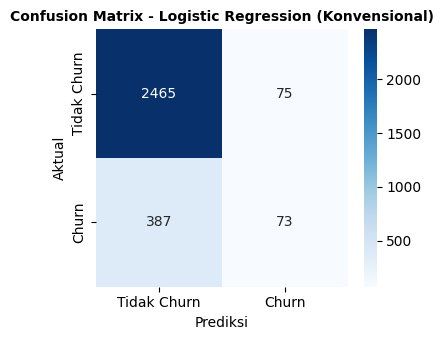

=== Random Forest (Ensemble Bagging) ===


Accuracy  : 0.8433
Precision : 0.4632
Recall    : 0.1370
F1-Score  : 0.2114



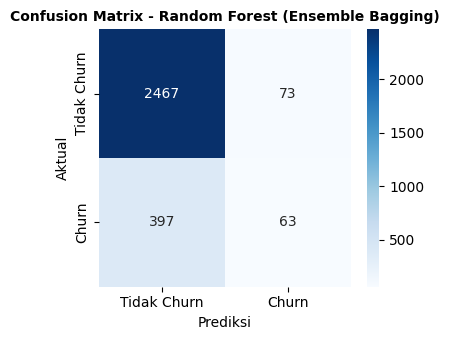

=== Voting Classifier (Ensemble Voting) ===


Accuracy  : 0.8467
Precision : 0.5000
Recall    : 0.0978
F1-Score  : 0.1636



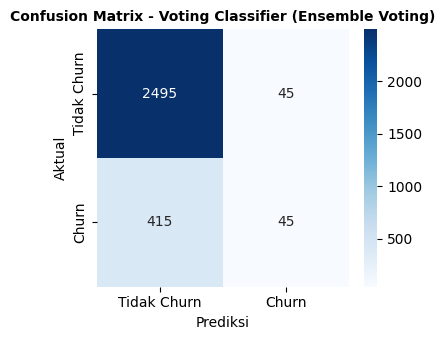

In [27]:
for name, model in models_prep.items():
    print(f"=== {name} ===")
    model.fit(X_train_scaled, y_train_p)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test_p, y_pred)
    prec = precision_score(y_test_p, y_pred, zero_division=0)
    rec = recall_score(y_test_p, y_pred, zero_division=0)
    f1 = f1_score(y_test_p, y_pred, zero_division=0)

    results_prep[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}\n")

    cm = confusion_matrix(y_test_p, y_pred)
    plt.figure(figsize=(4, 3.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Tidak Churn', 'Churn'],
                yticklabels=['Tidak Churn', 'Churn'])
    plt.title(f'Confusion Matrix - {name}', fontsize=10, fontweight='bold')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.tight_layout()
    plt.show()


#### Ringkasan Perbandingan Model (Dengan Preprocessing)

In [28]:
results_prep_df = pd.DataFrame(results_prep).T.sort_values('F1-Score', ascending=False)
results_prep_df


,Accuracy,Precision,Recall,F1-Score
Logistic Regression (Konvensional),0.846000,0.493243,0.158696,0.240132
Random Forest (Ensemble Bagging),0.843333,0.463235,0.136957,0.211409
Voting Classifier (Ensemble Voting),0.846667,0.500000,0.097826,0.163636


**Insight:**  
Preprocessing berhasil mempertahankan 15.000 baris data dan memperbanyak fitur menjadi 45 kolom. Namun, meski akurasi stabil di ~84%, F1-Score Random Forest turun drastis (dari 0.4457 menjadi 0.2114) karena fitur kategorikal baru menambahkan noise tanpa memberikan sinyal kuat untuk mendeteksi kelas minoritas (churn 15.3%).

Kesimpulan: Preprocessing dasar belum cukup. Langkah berikutnya wajib berfokus pada feature selection untuk membuang fitur tidak relevan dan hyperparameter tuning untuk mendongkrak performa deteksi churn.